# TrafficGuard: Spatial Smoothing Defence

This notebook implements Spatial Smoothing, a defensive mechanism designed to harden Computer Vision models against adversarial evasion attacks (like FGSM or PGD). 

### How it works:
Adversarial perturbations often rely on high-frequency, pixel-level noise that is imperceptible to humans but shifts the model's prediction. Spatial smoothing (e.g., local median or mean filtering) reduces this high-frequency noise, effectively "blurring" away the adversarial signal before it reaches the model.

## Imports
We use PyTorch for the model and the IBM Adversarial Robustness Toolbox (ART) for the defence implementation.

In [1]:
import torchvision.ops # Force registration of torchvision ops
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import torchvision
from torchvision import models, transforms

from art.estimators.classification import PyTorchClassifier
from art.defences.preprocessor import SpatialSmoothing

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## Load the Baseline Model
We reconstruct the ResNet18 architecture used in the TrafficGuard project, featuring 3 output classes: Low, Medium, and High congestion

In [2]:
def build_resnet18_model(num_classes=3):
    """Reconstructs the TrafficGuard ResNet18 architecture."""
    model = models.resnet18(weights=None)
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(p=0.3),
        nn.Linear(in_features, num_classes)
    )
    return model

model = build_resnet18_model().to(device)
model.eval() # Defence is applied during inference

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

## Configure Spatial Smoothing
We initialize the SpatialSmoothing preprocessor from ART. 
- window_size=3: Uses a 3x3 local window
- channels_first=True: Indicates the input format is (Batch, Channel, Height, Width)

In [3]:
smoothing_defence = SpatialSmoothing(window_size=3, channels_first=True)
print("Spatial Smoothing preprocessor initialized.")

Spatial Smoothing preprocessor initialized.


## Create the ART Classifier
We wrap our PyTorch model into an ART.PyTorchClassifier we include ImageNet normalization and our Spatial Smoothing defence as part of the pipeline.

In [4]:
# ImageNet normalization parameters used during training
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

classifier = PyTorchClassifier(
    model=model,
    loss=nn.CrossEntropyLoss(),
    input_shape=(3, 224, 224),
    nb_classes=3,
    preprocessing=(MEAN, STD),
    preprocessing_defences=[smoothing_defence],
    device_type="gpu" if torch.cuda.is_available() else "cpu"
)

## Visualizing the Defence
resize the image to 224x224 to match the model's input requirements and showcase the original image vs the smoothed one

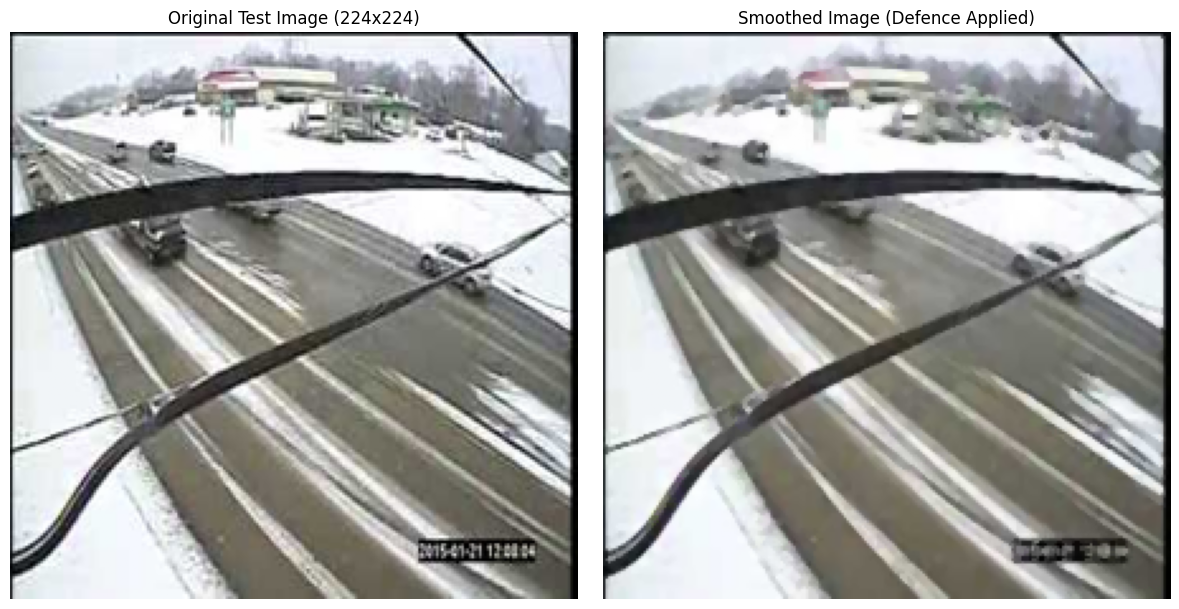

In [5]:
from PIL import Image
import os

# Absolute path to a sample image from the test set
sample_image_path = r"C:\Users\walee\Desktop\Walid\UCD\Summer Semester\Implementation\Work\trafficguard-p14\data\Data\MIO-TCD-Localization\MIO-TCD-Localization\test\00110593.jpg"

if os.path.exists(sample_image_path):
    # Load and preprocess image
    img = Image.open(sample_image_path).convert("RGB")
    
    # Resize to model input size (224x224)
    img_resized = img.resize((224, 224))
    
    # Convert to numpy array and transpose to (C, H, W)
    img_np = np.array(img_resized).astype(np.float32) / 255.0
    img_input = np.transpose(img_np, (2, 0, 1))
    img_input = np.expand_dims(img_input, axis=0) # Add batch dimension (1, 3, 224, 224)

    # Apply smoothing
    smoothed_img, _ = smoothing_defence(img_input)

    # Plot original vs smoothed
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    
    # Convert back to (H, W, C) for plotting
    axes[0].imshow(img_np)
    axes[0].set_title("Original Test Image (224x224)")
    axes[0].axis("off")
    
    axes[1].imshow(np.transpose(smoothed_img[0], (1, 2, 0)))
    axes[1].set_title("Smoothed Image (Defence Applied)")
    axes[1].axis("off")
    
    plt.tight_layout()
    plt.show()
        
else:
    print(f"Sample image not found at: {sample_image_path}")
    print("Please check if the data directory is correctly mounted.")

## Conclusion
The classifie object now contains a hardened version of the TrafficGuard model when we integrate into the dashboard, this defence will automatically process incoming frames, reducing the effectiveness of adversarial perturbations before our predictions are made.